This notebook includes runs related to unmixing by using:

1. A very simple MLP, of various different sizes. These sizes are:
    - [32,32]
    - [64^3]
    - [128^4]
    - [256^4]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [28]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [30]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.mlp import MLP
from src.dl.train import train_model

In [31]:
# Package imports
import torch
import torch.nn as nn

In [32]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [33]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [34]:
# Define model configs

models_list = [
    {'hidden_dim': [32, 32]},
    {'hidden_dim': [64, 64, 64]},
    {'hidden_dim': [128, 128, 128, 128]},
    {'hidden_dim': [256, 256, 256, 256]},
    {'hidden_dim': [512, 512, 512, 512, 512]},
    {'hidden_dim': [64, 1024, 1024, 1024, 1024, 64]},
    {'hidden_dim': [64, 2048, 2048, 4096, 2048, 2048, 64]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'mlp_32',
    'mlp_64_3layer',
    'mlp_128_4layer',
    'mlp_256_4layer',
    'mlp_512_5layer',
    'mlp_64_1k_5layer',
    'mlp_64_2k_7layer'
]

name_list = [
        'MLP_32',
        'MLP_64_3layer',
        'MLP_128_4layer',
        'MLP_256_4layer',
        'MLP_512_5layer',
        'MLP_64_1k_5layer',
        'MLP_64_2k_7layer'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'mlp' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.271079
Epoch 1/80, Step 2/47, Train Loss: 0.285110
Epoch 1/80, Step 3/47, Train Loss: 0.229047
Epoch 1/80, Step 4/47, Train Loss: 0.263935
Epoch 1/80, Step 5/47, Train Loss: 0.202485
Epoch 1/80, Step 6/47, Train Loss: 0.226096
Epoch 1/80, Step 7/47, Train Loss: 0.223814
Epoch 1/80, Step 8/47, Train Loss: 0.205084
Epoch 1/80, Step 9/47, Train Loss: 0.156019
Epoch 1/80, Step 10/47, Train Loss: 0.179473
Epoch 1/80, Step 11/47, Train Loss: 0.149925
Epoch 1/80, Step 12/47, Train Loss: 0.171875
Epoch 1/80, Step 13/47, Train Loss: 0.160035
Epoch 1/80, Step 14/47, Train Loss: 0.166564
Epoch 1/80, Step 15/47, Train Loss: 0.123795
Epoch 1/80, Step 16/47, Train Loss: 0.109082
Epoch 1/80, Step 17/47, Train Loss: 0.122168
Epoch 1/80, Step 18/47, Train Loss: 0.143583
Epoch 1/80, Step 19/47, Train Loss: 0.136545
Epoch 1/80, Step 20/47, Train Loss: 0.150791
Epoch 1/80, Step 21/47, Train Loss: 0.131134
Epoch 1/80, Step 22/47, Train Loss: 0.151142
Epoch 1/80, Step 23

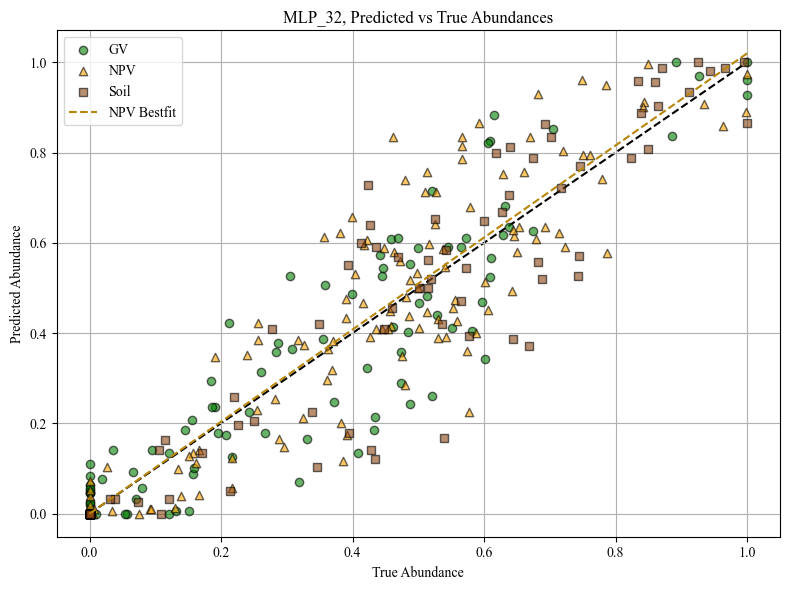

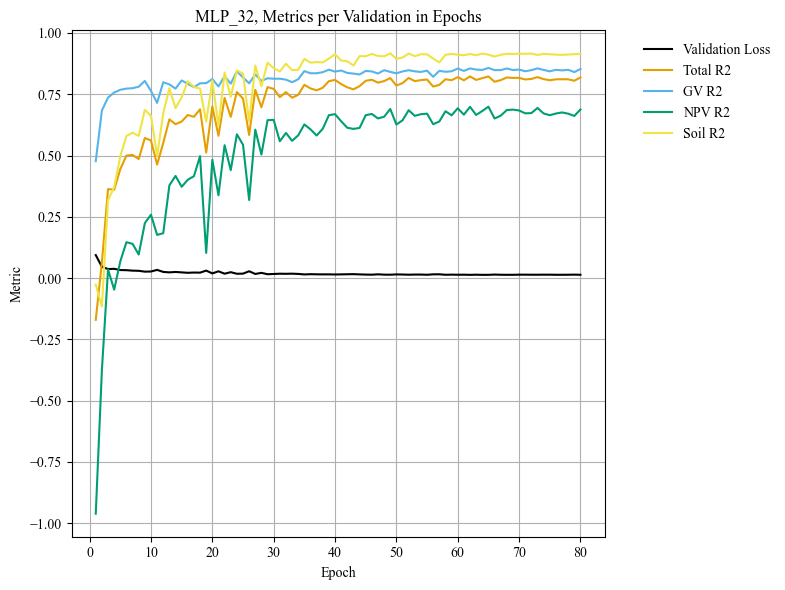

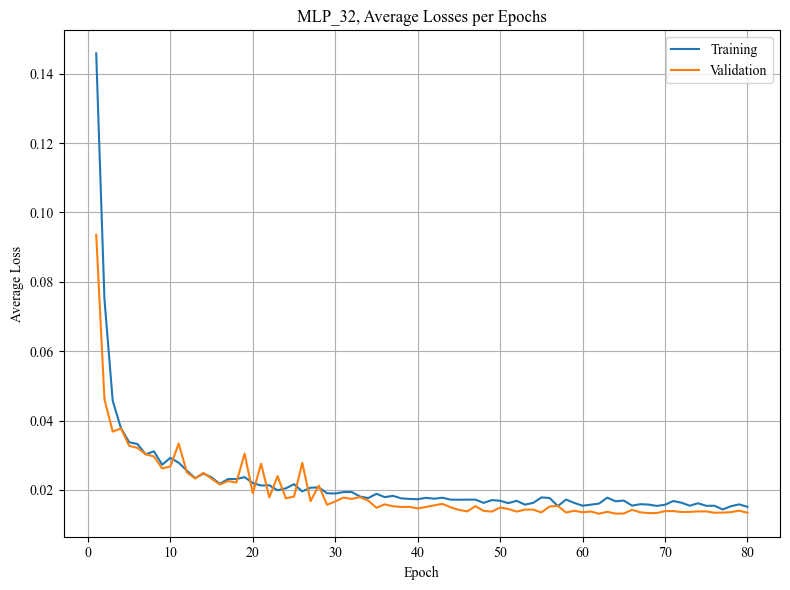

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.232733
Epoch 1/80, Step 2/47, Train Loss: 0.207603
Epoch 1/80, Step 3/47, Train Loss: 0.261338
Epoch 1/80, Step 4/47, Train Loss: 0.271561
Epoch 1/80, Step 5/47, Train Loss: 0.184122
Epoch 1/80, Step 6/47, Train Loss: 0.167854
Epoch 1/80, Step 7/47, Train Loss: 0.163308
Epoch 1/80, Step 8/47, Train Loss: 0.185733
Epoch 1/80, Step 9/47, Train Loss: 0.152238
Epoch 1/80, Step 10/47, Train Loss: 0.148611
Epoch 1/80, Step 11/47, Train Loss: 0.129567
Epoch 1/80, Step 12/47, Train Loss: 0.116071
Epoch 1/80, Step 13/47, Train Loss: 0.124513
Epoch 1/80, Step 14/47, Train Loss: 0.111207
Epoch 1/80, Step 15/47, Train Loss: 0.140594
Epoch 1/80, Step 16/47, Train Loss: 0.174709
Epoch 1/80, Step 17/47, Train Loss: 0.117682
Epoch 1/80, Step 18/47, Train Loss: 0.122618
Epoch 1/80, Step 19/47, Train Loss: 0.108014
Epoch 1/80, Step 20/47, Train Loss: 0.185559
Epoch 1/80, Step 21/47, Train Loss: 0.085458
Epoch 1/80, Step 22/47, Train Loss: 0.105315
Ep

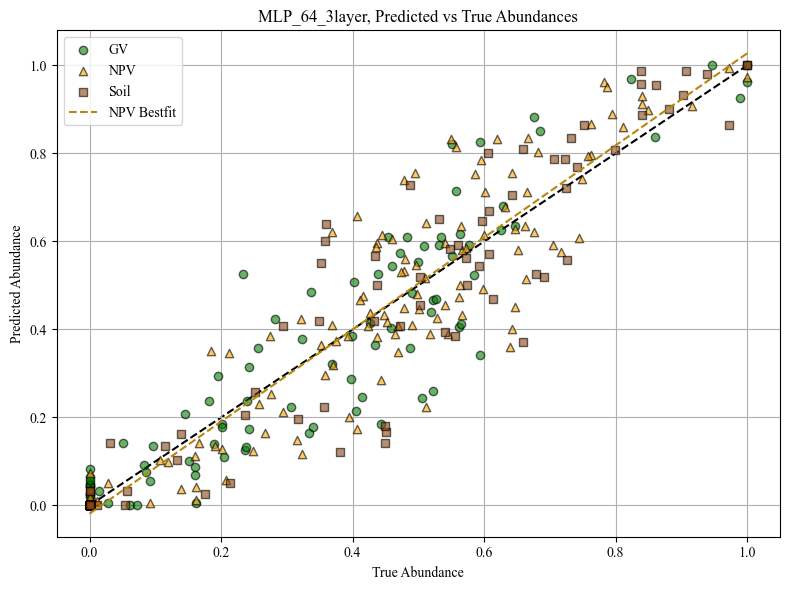

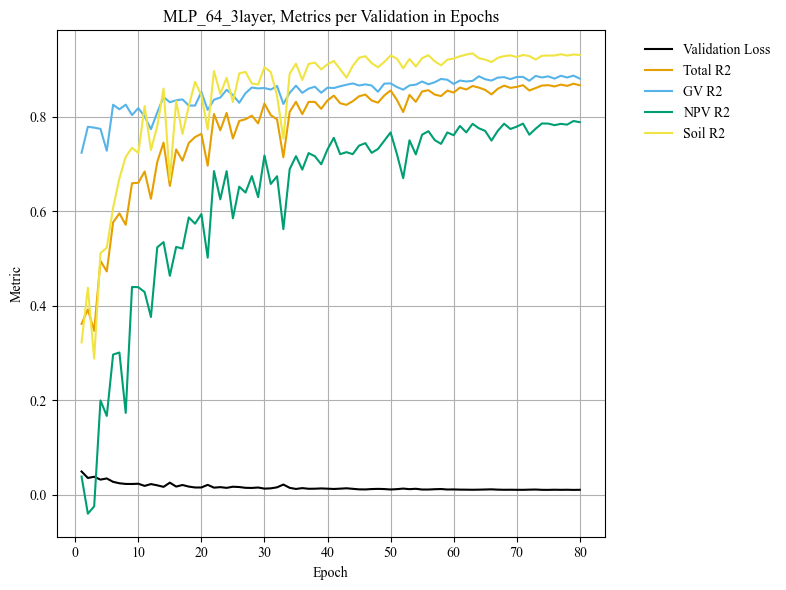

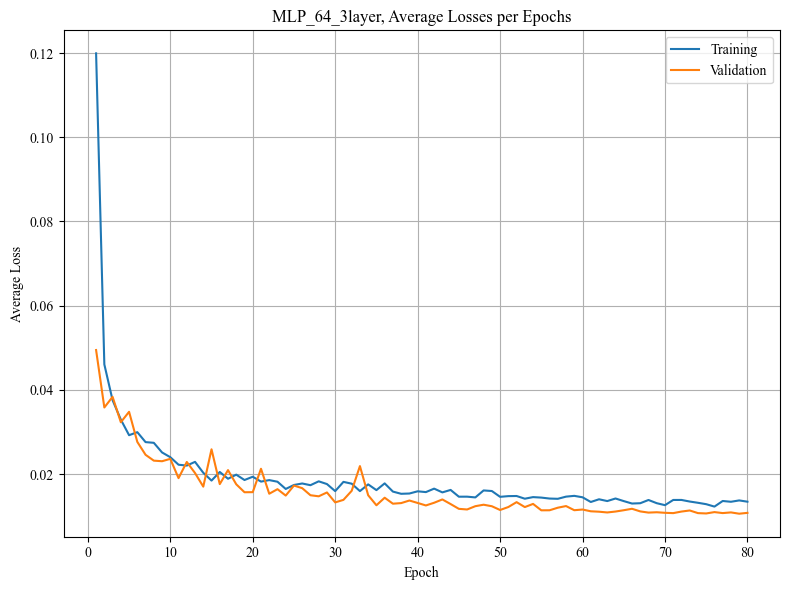

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.260601
Epoch 1/80, Step 2/47, Train Loss: 0.185594
Epoch 1/80, Step 3/47, Train Loss: 0.223614
Epoch 1/80, Step 4/47, Train Loss: 0.128820
Epoch 1/80, Step 5/47, Train Loss: 0.154543
Epoch 1/80, Step 6/47, Train Loss: 0.102649
Epoch 1/80, Step 7/47, Train Loss: 0.156839
Epoch 1/80, Step 8/47, Train Loss: 0.080636
Epoch 1/80, Step 9/47, Train Loss: 0.101025
Epoch 1/80, Step 10/47, Train Loss: 0.086769
Epoch 1/80, Step 11/47, Train Loss: 0.059026
Epoch 1/80, Step 12/47, Train Loss: 0.081533
Epoch 1/80, Step 13/47, Train Loss: 0.055614
Epoch 1/80, Step 14/47, Train Loss: 0.060153
Epoch 1/80, Step 15/47, Train Loss: 0.083085
Epoch 1/80, Step 16/47, Train Loss: 0.077121
Epoch 1/80, Step 17/47, Train Loss: 0.051289
Epoch 1/80, Step 18/47, Train Loss: 0.047326
Epoch 1/80, Step 19/47, Train Loss: 0.045486
Epoch 1/80, Step 20/47, Train Loss: 0.054691
Epoch 1/80, Step 21/47, Train Loss: 0.042817
Epoch 1/80, Step 22/47, Train Loss: 0.042480
Ep

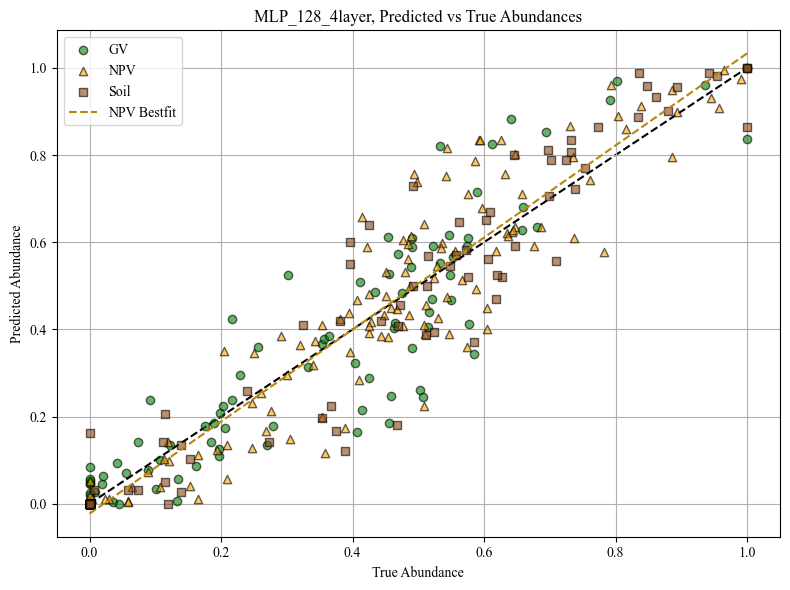

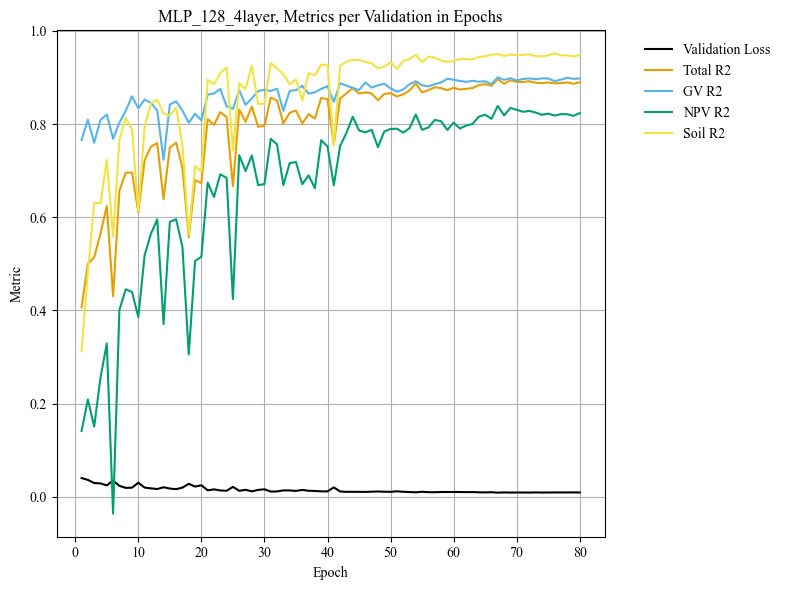

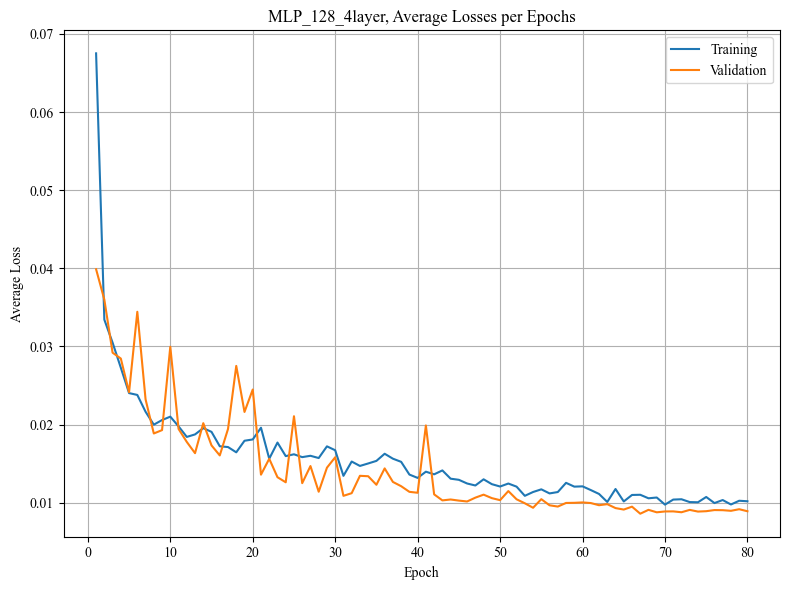

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.223374
Epoch 1/80, Step 2/47, Train Loss: 0.163135
Epoch 1/80, Step 3/47, Train Loss: 0.090522
Epoch 1/80, Step 4/47, Train Loss: 0.102840
Epoch 1/80, Step 5/47, Train Loss: 0.102589
Epoch 1/80, Step 6/47, Train Loss: 0.123486
Epoch 1/80, Step 7/47, Train Loss: 0.083943
Epoch 1/80, Step 8/47, Train Loss: 0.106664
Epoch 1/80, Step 9/47, Train Loss: 0.085350
Epoch 1/80, Step 10/47, Train Loss: 0.086633
Epoch 1/80, Step 11/47, Train Loss: 0.110094
Epoch 1/80, Step 12/47, Train Loss: 0.071500
Epoch 1/80, Step 13/47, Train Loss: 0.055464
Epoch 1/80, Step 14/47, Train Loss: 0.067713
Epoch 1/80, Step 15/47, Train Loss: 0.057082
Epoch 1/80, Step 16/47, Train Loss: 0.027598
Epoch 1/80, Step 17/47, Train Loss: 0.040224
Epoch 1/80, Step 18/47, Train Loss: 0.069516
Epoch 1/80, Step 19/47, Train Loss: 0.063261
Epoch 1/80, Step 20/47, Train Loss: 0.040369
Epoch 1/80, Step 21/47, Train Loss: 0.033745
Epoch 1/80, Step 22/47, Train Loss: 0.031382
Ep

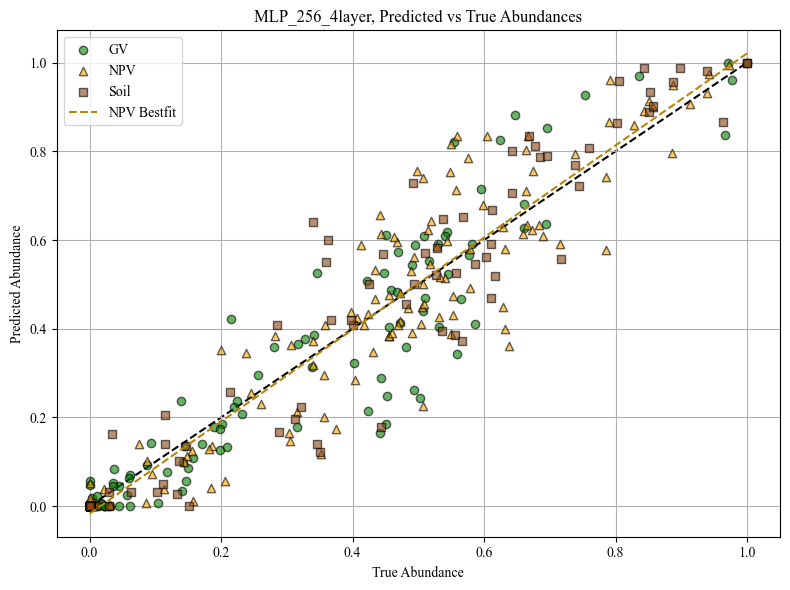

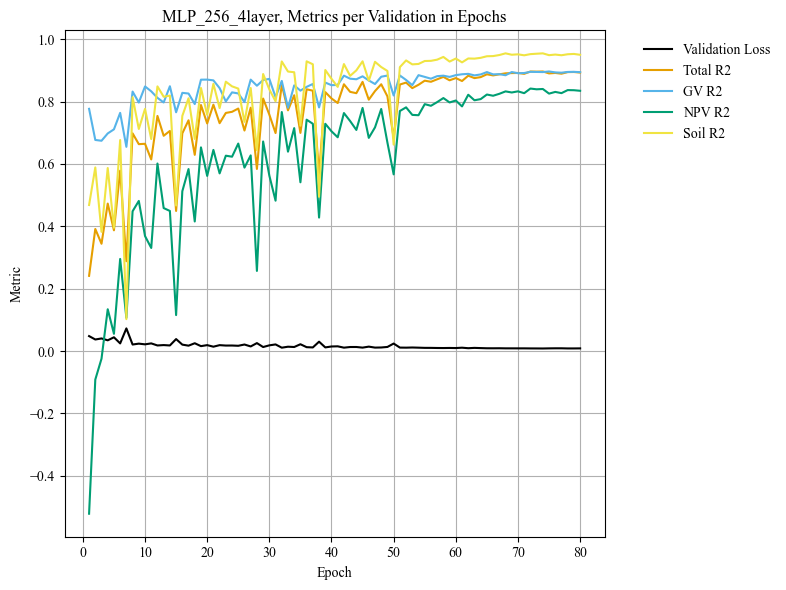

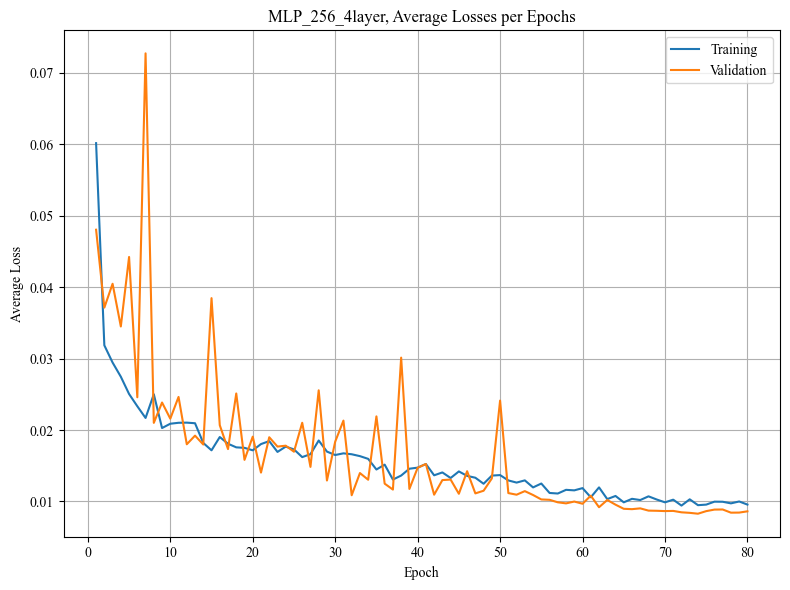

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.181778
Epoch 1/80, Step 2/47, Train Loss: 0.152363
Epoch 1/80, Step 3/47, Train Loss: 0.207930
Epoch 1/80, Step 4/47, Train Loss: 0.161169
Epoch 1/80, Step 5/47, Train Loss: 0.162947
Epoch 1/80, Step 6/47, Train Loss: 0.097682
Epoch 1/80, Step 7/47, Train Loss: 0.099817
Epoch 1/80, Step 8/47, Train Loss: 0.059820
Epoch 1/80, Step 9/47, Train Loss: 0.077100
Epoch 1/80, Step 10/47, Train Loss: 0.060712
Epoch 1/80, Step 11/47, Train Loss: 0.063391
Epoch 1/80, Step 12/47, Train Loss: 0.107606
Epoch 1/80, Step 13/47, Train Loss: 0.082790
Epoch 1/80, Step 14/47, Train Loss: 0.077968
Epoch 1/80, Step 15/47, Train Loss: 0.060069
Epoch 1/80, Step 16/47, Train Loss: 0.050683
Epoch 1/80, Step 17/47, Train Loss: 0.034702
Epoch 1/80, Step 18/47, Train Loss: 0.031466
Epoch 1/80, Step 19/47, Train Loss: 0.064723
Epoch 1/80, Step 20/47, Train Loss: 0.041203
Epoch 1/80, Step 21/47, Train Loss: 0.065879
Epoch 1/80, Step 22/47, Train Loss: 0.044333
Ep

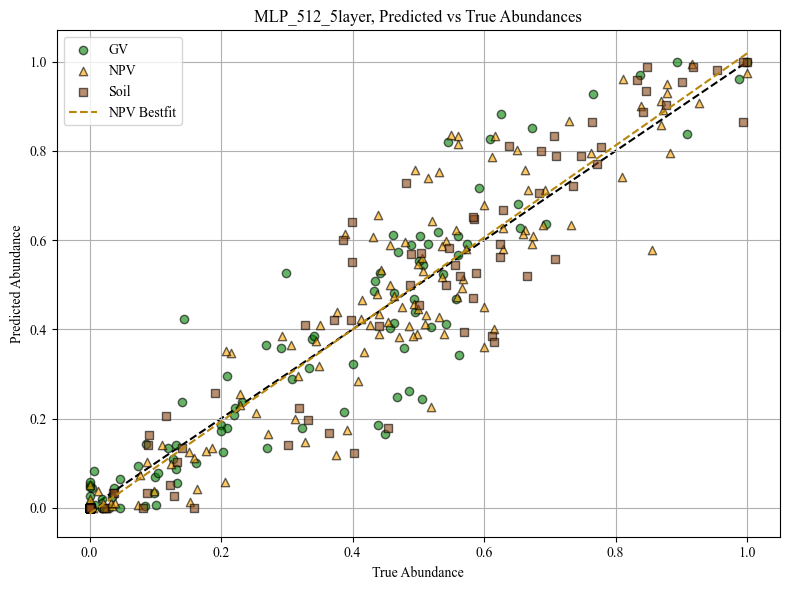

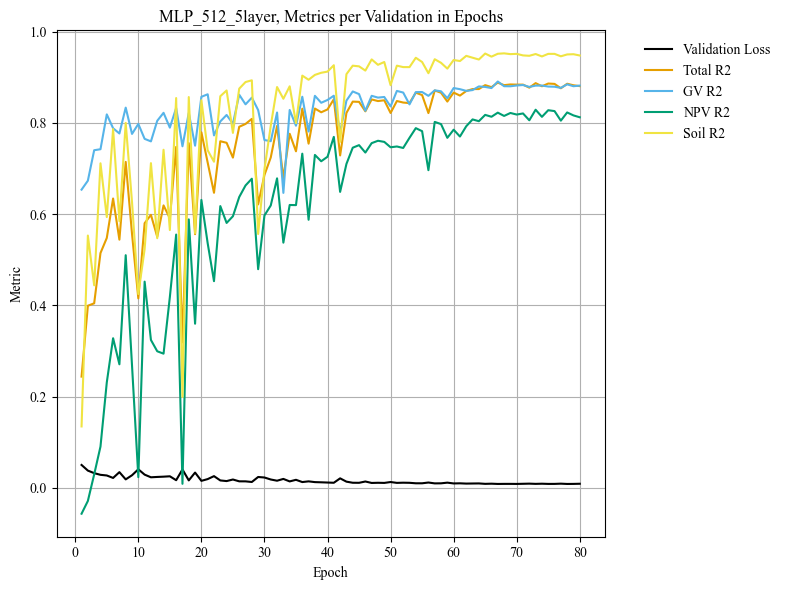

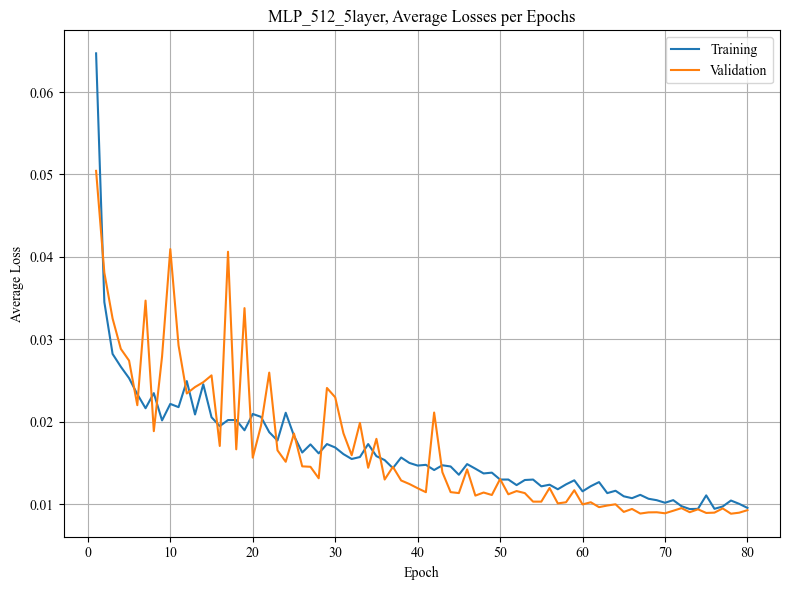

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.154284
Epoch 1/80, Step 2/47, Train Loss: 0.223447
Epoch 1/80, Step 3/47, Train Loss: 0.135732
Epoch 1/80, Step 4/47, Train Loss: 0.133319
Epoch 1/80, Step 5/47, Train Loss: 0.117932
Epoch 1/80, Step 6/47, Train Loss: 0.122098
Epoch 1/80, Step 7/47, Train Loss: 0.123085
Epoch 1/80, Step 8/47, Train Loss: 0.131448
Epoch 1/80, Step 9/47, Train Loss: 0.160713
Epoch 1/80, Step 10/47, Train Loss: 0.135231
Epoch 1/80, Step 11/47, Train Loss: 0.153324
Epoch 1/80, Step 12/47, Train Loss: 0.136919
Epoch 1/80, Step 13/47, Train Loss: 0.093371
Epoch 1/80, Step 14/47, Train Loss: 0.118378
Epoch 1/80, Step 15/47, Train Loss: 0.111864
Epoch 1/80, Step 16/47, Train Loss: 0.107846
Epoch 1/80, Step 17/47, Train Loss: 0.099188
Epoch 1/80, Step 18/47, Train Loss: 0.130128
Epoch 1/80, Step 19/47, Train Loss: 0.098126
Epoch 1/80, Step 20/47, Train Loss: 0.108382
Epoch 1/80, Step 21/47, Train Loss: 0.105530
Epoch 1/80, Step 22/47, Train Loss: 0.091199
Ep

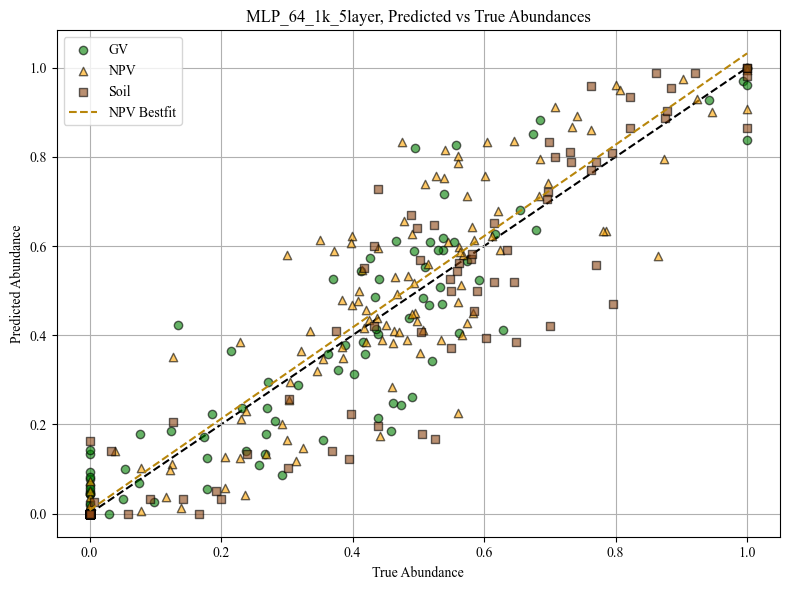

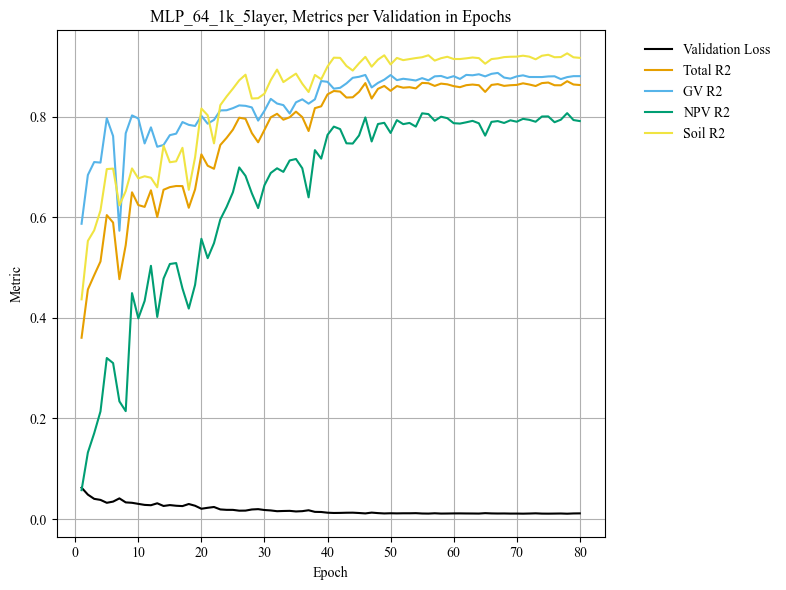

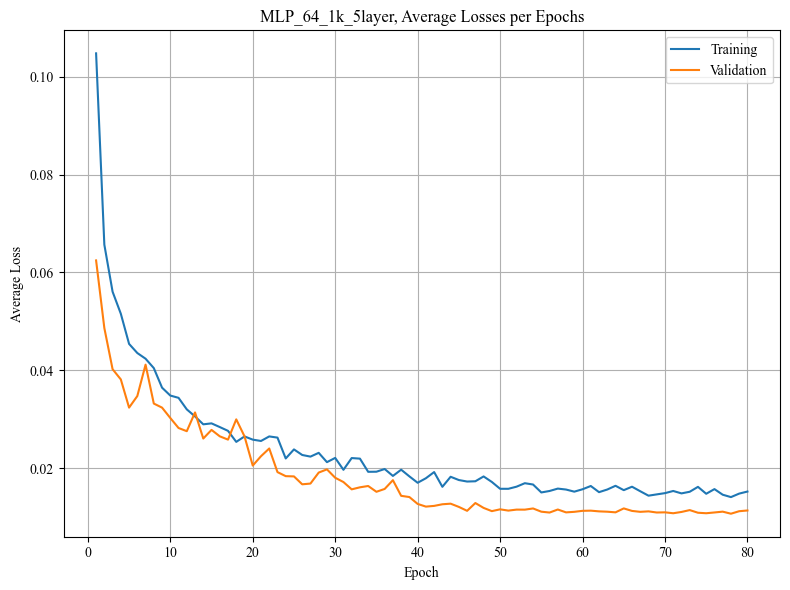

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.256412
Epoch 1/80, Step 2/47, Train Loss: 0.125144
Epoch 1/80, Step 3/47, Train Loss: 0.145742
Epoch 1/80, Step 4/47, Train Loss: 0.099381
Epoch 1/80, Step 5/47, Train Loss: 0.128477
Epoch 1/80, Step 6/47, Train Loss: 0.100712
Epoch 1/80, Step 7/47, Train Loss: 0.084411
Epoch 1/80, Step 8/47, Train Loss: 0.092890
Epoch 1/80, Step 9/47, Train Loss: 0.048446
Epoch 1/80, Step 10/47, Train Loss: 0.112978
Epoch 1/80, Step 11/47, Train Loss: 0.112628
Epoch 1/80, Step 12/47, Train Loss: 0.065356
Epoch 1/80, Step 13/47, Train Loss: 0.054384
Epoch 1/80, Step 14/47, Train Loss: 0.092054
Epoch 1/80, Step 15/47, Train Loss: 0.060435
Epoch 1/80, Step 16/47, Train Loss: 0.047485
Epoch 1/80, Step 17/47, Train Loss: 0.047737
Epoch 1/80, Step 18/47, Train Loss: 0.071586
Epoch 1/80, Step 19/47, Train Loss: 0.072818
Epoch 1/80, Step 20/47, Train Loss: 0.083091
Epoch 1/80, Step 21/47, Train Loss: 0.064765
Epoch 1/80, Step 22/47, Train Loss: 0.065781
Ep

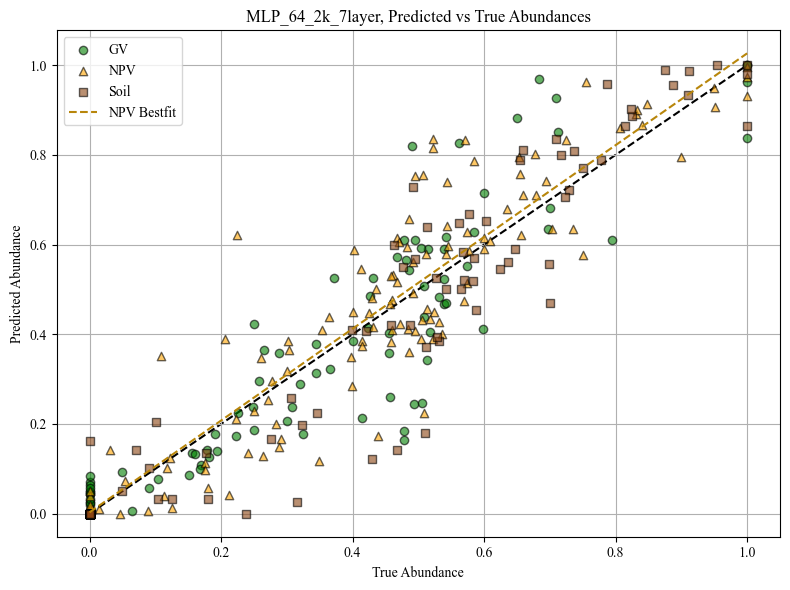

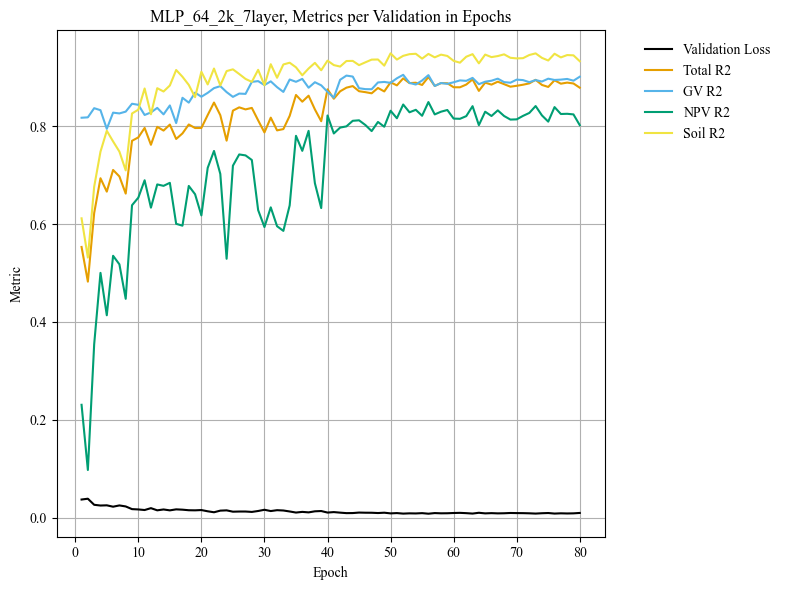

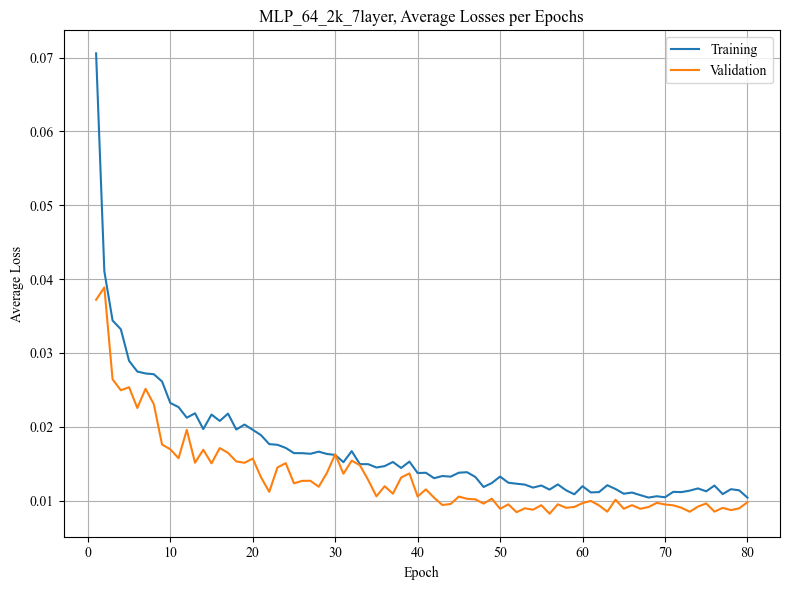

Testing complete


In [35]:
for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1700], batch_size=32)
    model = MLP(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()


    model_losses_step, model_losses_average, model_metrics_epoch, model_metrics_total = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )
